<a href="https://colab.research.google.com/github/gre1wy/Machine_Learning/blob/main/lab2/lab2a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1573]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron as Perceptron_S
from sklearn.model_selection import cross_val_score

In [1574]:
data = pd.read_csv('/content/drive/MyDrive/data04.csv', names=['x1', 'x2', 'y'], delimiter=';')

In [1575]:
data

,x1,x2,y
0,0.136,0.574,0
1,0.579,0.675,1
2,0.719,0.975,1
3,0.771,0.891,1
4,0.293,0.310,0
...,...,...,...
95,0.802,0.592,1
96,0.622,0.584,1
97,0.644,0.700,1
98,0.487,0.641,0


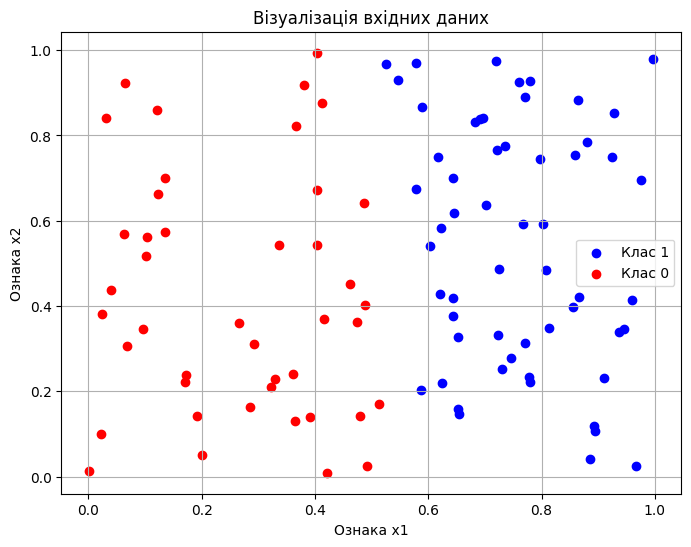

In [1576]:
plt.figure(figsize=(8, 6))
plt.scatter(data[data['y'] == 1]['x1'],
            data[data['y'] == 1]['x2'],
            color='blue',
            label='Клас 1')
plt.scatter(data[data['y'] == 0]['x1'],
            data[data['y'] == 0]['x2'],
            color='red',
            label='Клас 0')

plt.title('Візуалізація вхідних даних')
plt.xlabel('Ознака x1')
plt.ylabel('Ознака x2')
plt.legend()
plt.grid(True)
plt.show()

In [1577]:
X = data[['x1', 'x2']].to_numpy()

In [1578]:
y = data['y'].to_numpy()
y[y == 0] = -1

# Vanilla

In [1579]:
class Perceptron():
  def __init__(self, learning_rate=0.01, n_iters=1000):
      self.learning_rate = learning_rate
      self.n_iters = n_iters
      self.weights = None

  def fit(self, X, y):
    n_samples, n_features = X.shape
    X_b = np.hstack((X, np.ones((n_samples, 1))))
    self.weights = np.zeros(n_features+1)
    X_prime = X_b * y[:, np.newaxis]
    for _ in range(self.n_iters):
      np.random.shuffle(X_prime)
      for i in X_prime:
        if np.dot(self.weights, i) <= 0:
          self.weights += self.learning_rate * i

  def predict(self, X):
    n_samples = X.shape[0]
    X_b = np.hstack((X, np.ones((n_samples, 1))))
    y_predicted = np.where(np.dot(X_b, self.weights) >= 0, 1, -1)
    return y_predicted

  def score(self, X, y):
    y_pred = self.predict(X)
    return accuracy_score(y, y_pred)

  def get_params(self, deep=True):
    return {"learning_rate": self.learning_rate, "n_iters": self.n_iters}

  def set_params(self, **params):
    for param, value in params.items():
      setattr(self, param, value)
    return self

In [1580]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=3
)


In [1581]:
percepton_test = Perceptron()

percepton_test.fit(X_train, y_train)

In [1582]:
percepton_test.weights

array([ 0.05669,  0.00483, -0.03   ])

In [1583]:
y_predicted = percepton_test.predict(X_test)

In [1584]:
accuracy = accuracy_score(y_test, y_predicted)
accuracy

0.9666666666666667

In [1585]:
scores = cross_val_score(percepton_test, X, y, cv=10, scoring='accuracy')
scores

array([1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 0.9])

# Sklearn

In [1586]:
perceptron = Perceptron_S(max_iter=1000, eta0=0.01)
perceptron.fit(X_train, y_train)

predictions = perceptron.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
accuracy

0.9666666666666667

In [1587]:
scores = cross_val_score(perceptron, X, y, cv=10, scoring='accuracy')
scores

array([1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 0.8])